# 04 - Simulador de Encuestas de Compradores

**Pregunta de negocio:** ¿Cómo es nuestra población de compradores?

## Objetivos
- Generar 500 encuestas con correlaciones demográficas
- Explorar distribuciones con visualizaciones
- Verificar correlaciones intencionales (edad→tipo, ingreso→eléctrico)

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.insert(0, project_root)

from src.simulator import SurveyGenerator

## 1. Generar encuestas

In [2]:
sg = SurveyGenerator(seed=42)
surveys = sg.generate_surveys(n_surveys=500)

# Crear grupo de edad
bins = [18, 25, 35, 45, 55, 70]
surveys["age_group"] = pd.cut(surveys["age"], bins=bins, labels=["18-25", "26-35", "36-45", "46-55", "56-70"])

print(f"Encuestas: {len(surveys)}")
surveys.head()

Encuestas: 500


,survey_id,vehicle_id,purchase_date,age,gender,income_bracket,education,region,purchase_reason,expected_usage,vehicle_type_purchased,driving_style,km_driven,satisfaction_score,would_recommend,age_group
0,ce2cb7ae-d30f-466f-bea0-ac61995f7794,c3c5ba8c-d81d-4b4b-8a8f-b1705101b1bc,2025-03-08,51,femenino,medio-alto,universidad,sur,rendimiento,mixto,deportivo,aggressive,9433.0,2,False,46-55
1,95ad9cda-fbfb-4858-a6d1-92235526771c,0c6b25f4-d841-4842-9ab3-4cfd17a0ce23,2025-12-20,44,femenino,medio,universidad,norte,economia,carretera,electrico,aggressive,23910.0,2,False,36-45
2,8c962a37-ef11-45d8-857b-6fa0e3e29ba1,7acba6c9-754f-4cae-ab67-4142d1714b42,2025-01-28,65,masculino,medio,universidad,este,economia,ciudad,hibrido,normal,29188.0,2,False,56-70
3,a5f86029-5d03-4761-a03f-0dc75d38712e,7b391f5b-76b5-4f7c-8859-bdb453206b47,2025-10-20,30,masculino,medio,posgrado,sur,rendimiento,carretera,gasolina,aggressive,31059.0,2,False,26-35
4,3edcfac8-9a95-4bbd-b7d9-b911994aa52e,afdacd39-f603-47ce-b497-27cda21bd6cd,2025-07-04,34,femenino,medio-bajo,universidad,centro,economia,ciudad,hibrido,normal,22629.0,2,False,26-35


## 2. Distribuciones demográficas

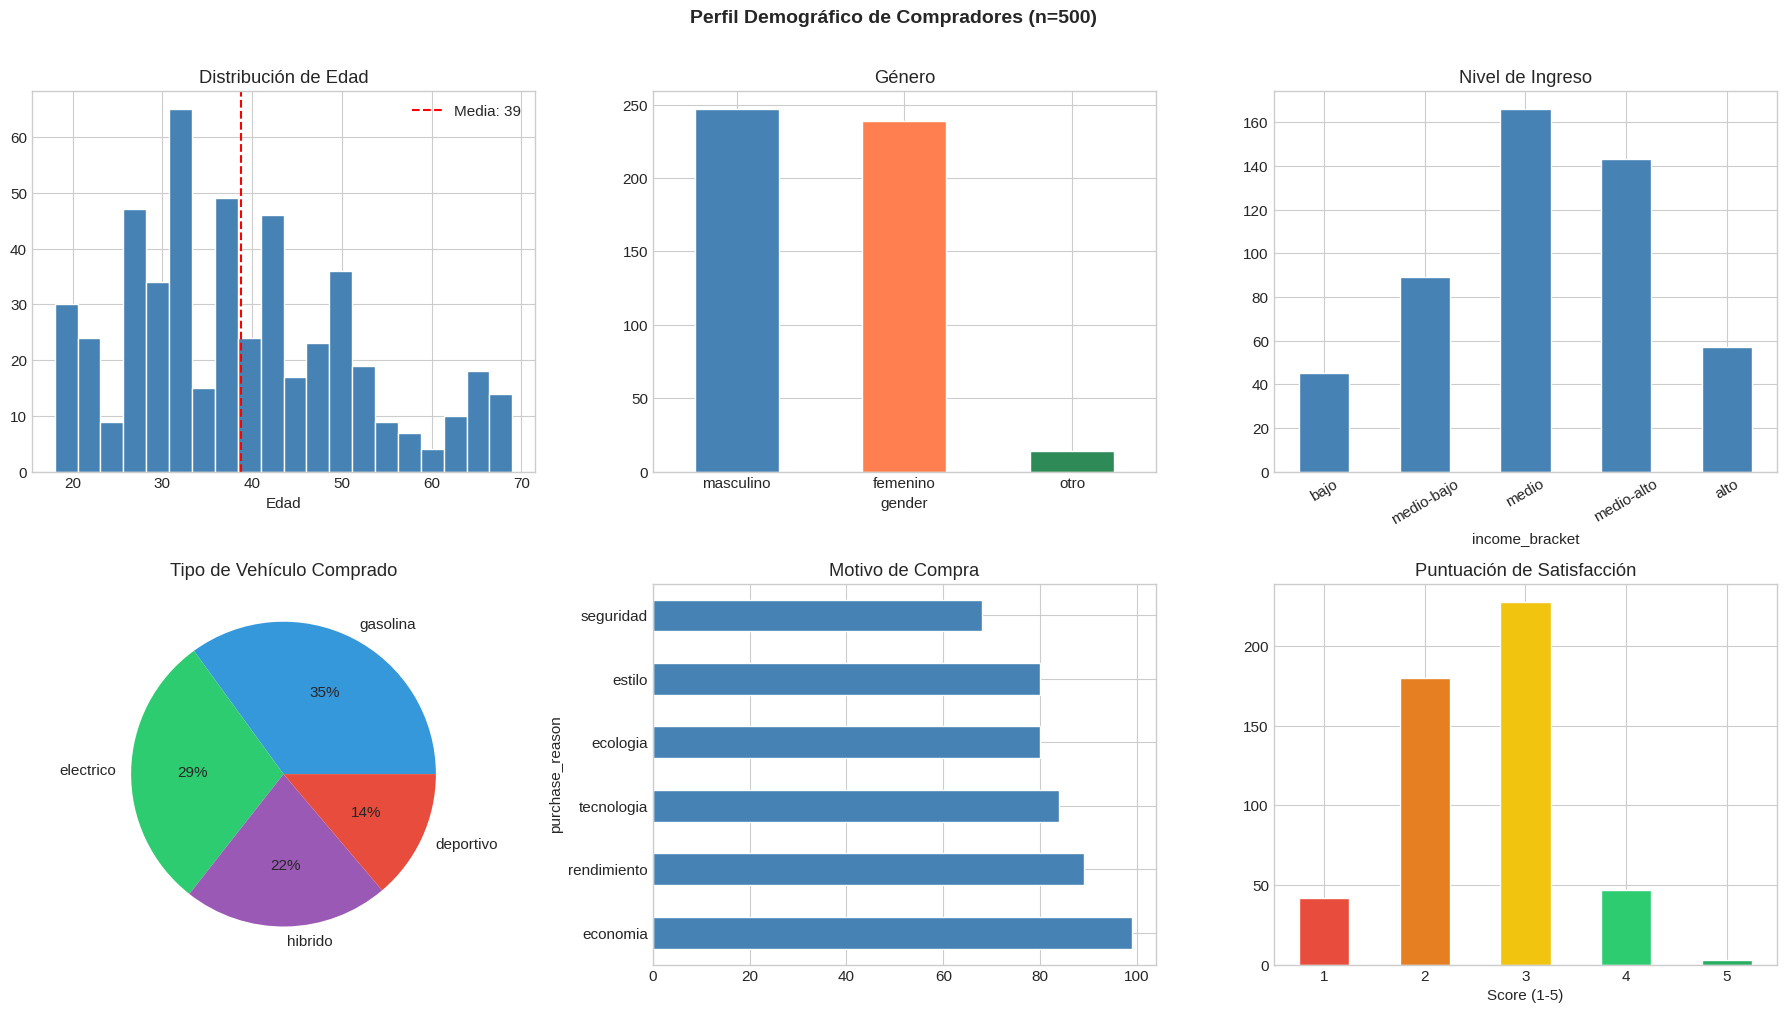

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Edad
axes[0, 0].hist(surveys['age'], bins=20, color='steelblue', edgecolor='white')
axes[0, 0].axvline(surveys['age'].mean(), color='red', linestyle='--', label=f'Media: {surveys["age"].mean():.0f}')
axes[0, 0].set_xlabel('Edad')
axes[0, 0].set_title('Distribución de Edad')
axes[0, 0].legend()

# Género
surveys['gender'].value_counts().plot(kind='bar', ax=axes[0, 1], color=['steelblue', 'coral', 'seagreen'], edgecolor='white')
axes[0, 1].set_title('Género')
axes[0, 1].tick_params(axis='x', rotation=0)

# Ingreso
income_order = ['bajo', 'medio-bajo', 'medio', 'medio-alto', 'alto']
surveys['income_bracket'].value_counts().reindex(income_order).plot(
    kind='bar', ax=axes[0, 2], color='steelblue', edgecolor='white')
axes[0, 2].set_title('Nivel de Ingreso')
axes[0, 2].tick_params(axis='x', rotation=30)

# Tipo de vehículo
vtype_colors = {'electrico': '#2ecc71', 'gasolina': '#3498db', 'hibrido': '#9b59b6', 'deportivo': '#e74c3c'}
vc = surveys['vehicle_type_purchased'].value_counts()
axes[1, 0].pie(vc.values, labels=vc.index, autopct='%1.0f%%',
               colors=[vtype_colors.get(t, 'gray') for t in vc.index])
axes[1, 0].set_title('Tipo de Vehículo Comprado')

# Motivo de compra
surveys['purchase_reason'].value_counts().plot(kind='barh', ax=axes[1, 1], color='steelblue', edgecolor='white')
axes[1, 1].set_title('Motivo de Compra')

# Satisfacción
surveys['satisfaction_score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1, 2], color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60'], edgecolor='white')
axes[1, 2].set_title('Puntuación de Satisfacción')
axes[1, 2].set_xlabel('Score (1-5)')
axes[1, 2].tick_params(axis='x', rotation=0)

plt.suptitle('Perfil Demográfico de Compradores (n=500)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Verificación de correlaciones embebidas

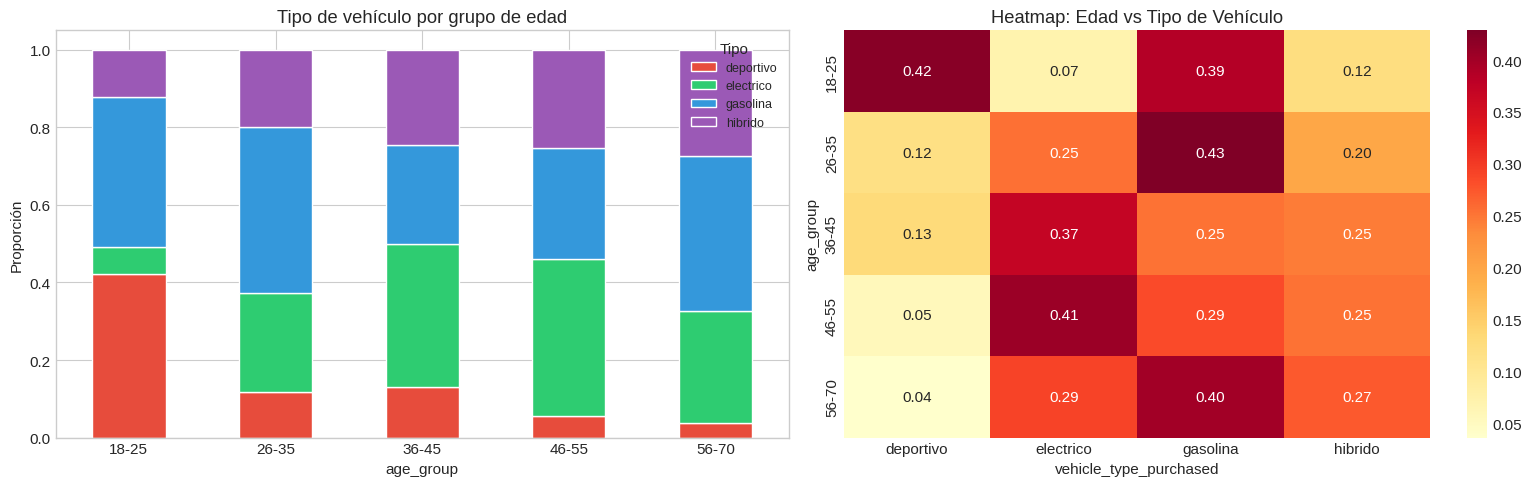

→ Los jóvenes (18-25) compran más deportivos, los mayores más híbridos


In [4]:
# Correlación 1: Edad → Tipo de vehículo
tabla_edad_tipo = pd.crosstab(surveys['age_group'], surveys['vehicle_type_purchased'], normalize='index')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

tabla_edad_tipo.plot(kind='bar', stacked=True, ax=axes[0],
                     color=[vtype_colors.get(c, 'gray') for c in tabla_edad_tipo.columns],
                     edgecolor='white')
axes[0].set_ylabel('Proporción')
axes[0].set_title('Tipo de vehículo por grupo de edad')
axes[0].legend(title='Tipo', fontsize=9)
axes[0].tick_params(axis='x', rotation=0)

# Heatmap
sns.heatmap(tabla_edad_tipo, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Heatmap: Edad vs Tipo de Vehículo')

plt.tight_layout()
plt.show()
print("→ Los jóvenes (18-25) compran más deportivos, los mayores más híbridos")

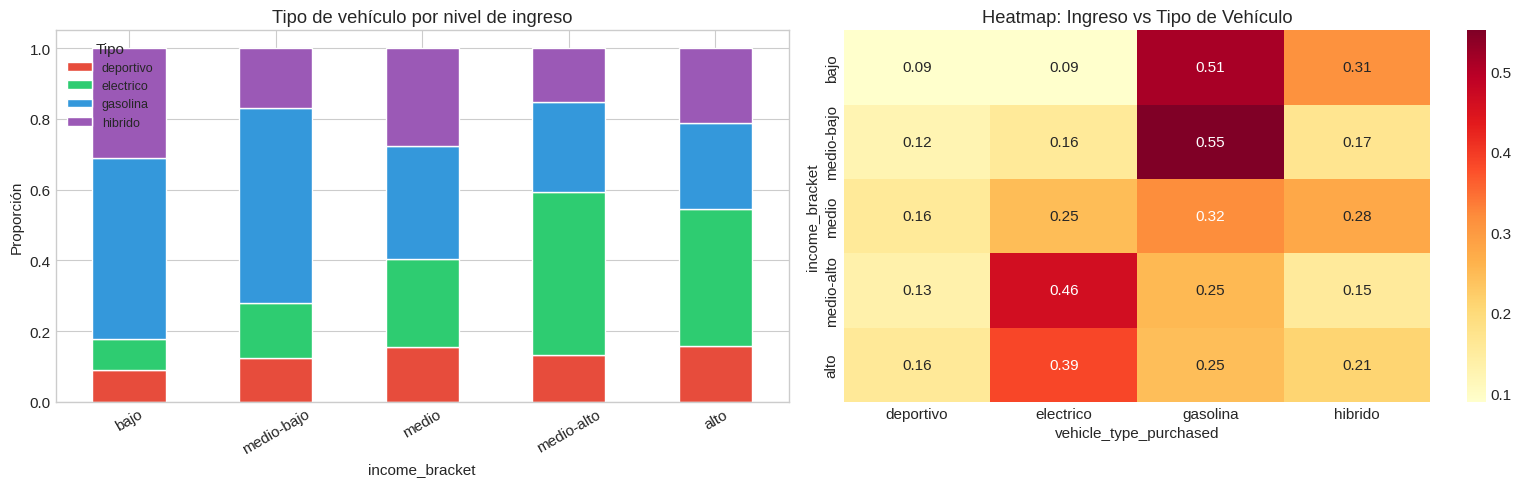

→ Ingreso alto = más vehículos eléctricos


In [5]:
# Correlación 2: Ingreso → Tipo de vehículo
tabla_ingreso = pd.crosstab(surveys['income_bracket'], surveys['vehicle_type_purchased'], normalize='index')
tabla_ingreso = tabla_ingreso.reindex(income_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

tabla_ingreso.plot(kind='bar', stacked=True, ax=axes[0],
                   color=[vtype_colors.get(c, 'gray') for c in tabla_ingreso.columns],
                   edgecolor='white')
axes[0].set_ylabel('Proporción')
axes[0].set_title('Tipo de vehículo por nivel de ingreso')
axes[0].legend(title='Tipo', fontsize=9)
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(tabla_ingreso, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Heatmap: Ingreso vs Tipo de Vehículo')

plt.tight_layout()
plt.show()
print("→ Ingreso alto = más vehículos eléctricos")

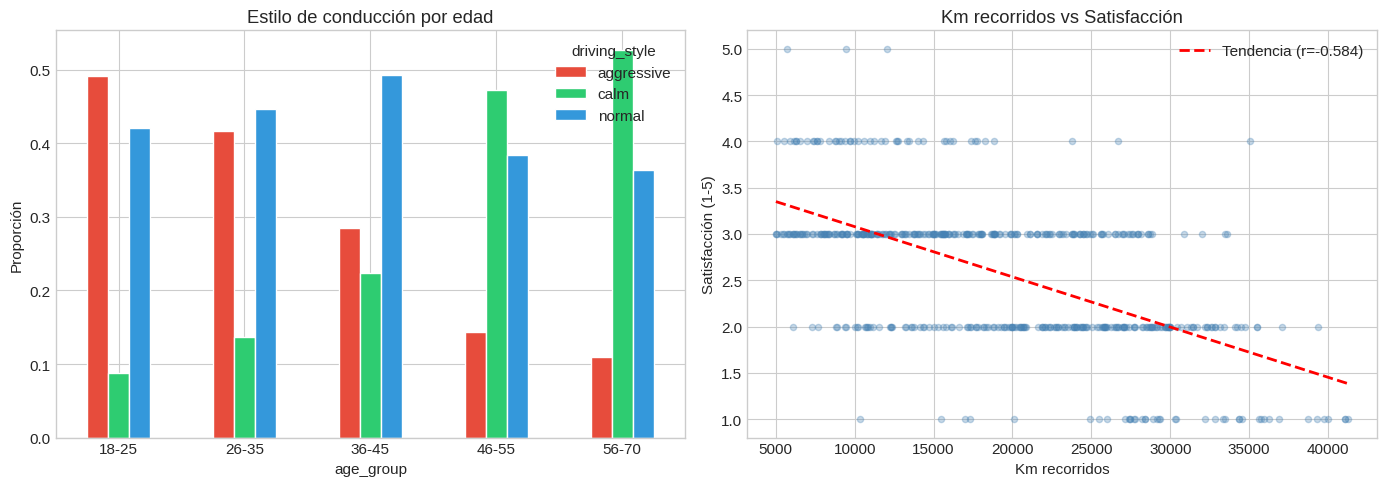

→ Jóvenes más agresivos, más km = menor satisfacción


In [6]:
# Correlación 3: Edad → Estilo de conducción
tabla_style = pd.crosstab(surveys['age_group'], surveys['driving_style'], normalize='index')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

style_colors = {'calm': '#2ecc71', 'normal': '#3498db', 'aggressive': '#e74c3c'}
tabla_style.plot(kind='bar', ax=axes[0],
                 color=[style_colors.get(c, 'gray') for c in tabla_style.columns],
                 edgecolor='white')
axes[0].set_ylabel('Proporción')
axes[0].set_title('Estilo de conducción por edad')
axes[0].tick_params(axis='x', rotation=0)

# Correlación 4: Km → Satisfacción
axes[1].scatter(surveys['km_driven'], surveys['satisfaction_score'],
                alpha=0.3, s=20, color='steelblue')
# Línea de tendencia
z = np.polyfit(surveys['km_driven'], surveys['satisfaction_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(surveys['km_driven'].min(), surveys['km_driven'].max(), 100)
axes[1].plot(x_line, p(x_line), 'r--', linewidth=2,
             label=f'Tendencia (r={surveys["km_driven"].corr(surveys["satisfaction_score"]):.3f})')
axes[1].set_xlabel('Km recorridos')
axes[1].set_ylabel('Satisfacción (1-5)')
axes[1].set_title('Km recorridos vs Satisfacción')
axes[1].legend()

plt.tight_layout()
plt.show()
print("→ Jóvenes más agresivos, más km = menor satisfacción")

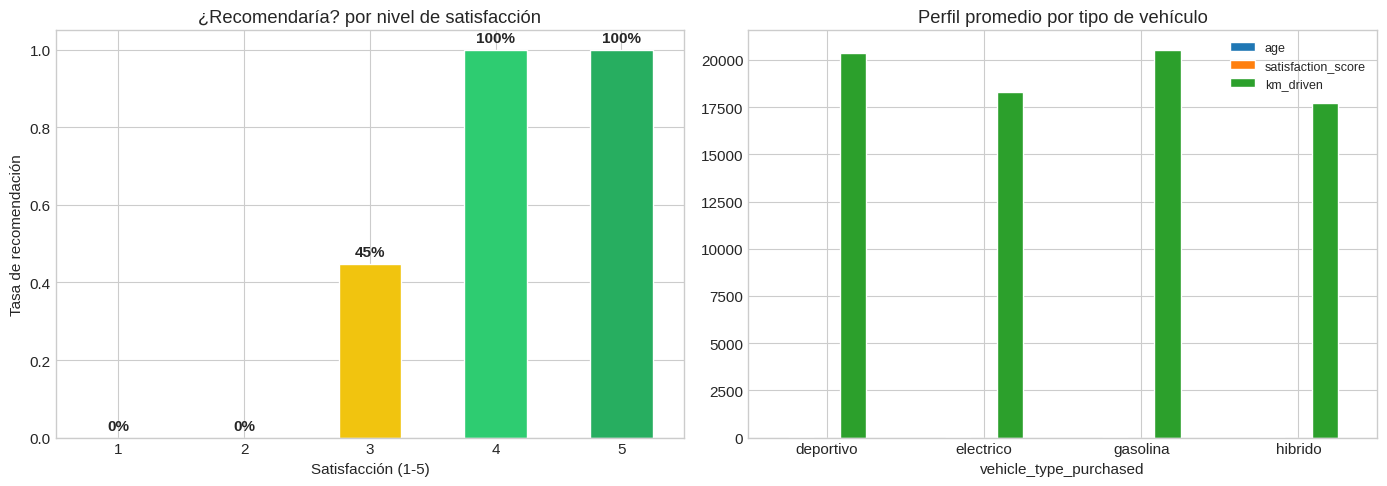

In [7]:
# Satisfacción → Recomendación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

recommend_rate = surveys.groupby('satisfaction_score')['would_recommend'].mean()
bar_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
recommend_rate.plot(kind='bar', ax=axes[0], color=bar_colors, edgecolor='white')
axes[0].set_ylabel('Tasa de recomendación')
axes[0].set_title('¿Recomendaría? por nivel de satisfacción')
axes[0].set_xlabel('Satisfacción (1-5)')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(recommend_rate):
    axes[0].text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')

# Perfil promedio por tipo
perfil = surveys.groupby('vehicle_type_purchased').agg({
    'age': 'mean',
    'satisfaction_score': 'mean',
    'km_driven': 'mean',
})
perfil.plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title('Perfil promedio por tipo de vehículo')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. Mapa de correlaciones numéricas

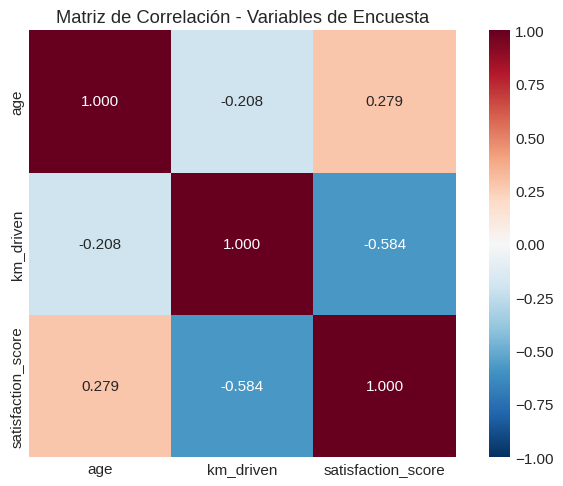

In [8]:
# Correlación entre variables numéricas
numeric_cols = ['age', 'km_driven', 'satisfaction_score']
corr = surveys[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Matriz de Correlación - Variables de Encuesta')
plt.tight_layout()
plt.show()

## Resumen

### Respuesta a la pregunta de negocio:
> **¿Cómo es nuestra población de compradores?**
>
> Segmentos claros: jóvenes prefieren deportivos con conducción agresiva,
> ingresos altos optan por eléctricos, compradores por economía eligen híbridos.
> La satisfacción decrece con los km, y es el principal predictor de recomendación.

### Siguiente notebook:
→ `05_data_merging.ipynb`: Unir telemetría + encuestas